# 1. Conteúdo e autoria com influência limitada

Comparamos cinco configurações locais, sem alterar o baseline: autor livre no
detector, conteúdo sem autor, conteúdo com ajuste limitado de autoria e duas
configurações removendo TTR/diversidade. Não treinamos com Fake. Scores não são
probabilidades; anomalia não comprova falsidade.

**Protocolo fixado antes desta execução:** threshold q95 de True de validação;
faixa de atenção q90–q95; somente autoria ausente nessa faixa pode elevar o alerta.
Autor presente ou extração desconhecida são neutros. Não há peso otimizado com Fake.

Mantemos o split por notícia (seed 42) para continuidade e avaliamos agrupamento
por pares temáticos com seeds 42, 43 e 44. As Fake pareadas com True de treino
ficam em quarentena. Todo o corpus já foi explorado: são análises de sensibilidade,
não um teste externo intocado nem três amostras independentes.

Execute na pasta deste notebook, com o ambiente `.venv` e os módulos vizinhos
`controlled_author.py` e `controlled_author_evaluation.py`. O carregamento e as
fórmulas das 15 features originais abaixo foram preservados; cada configuração
seleciona explicitamente suas entradas. Plano: `specs/controlled-author-plan.md`.


## 2. Imports

Semente fixa de 42. As versões do ambiente ficam registradas para reprodução.

In [1]:
from pathlib import Path
from urllib.request import urlopen
from zipfile import ZipFile
from itertools import combinations
from importlib.metadata import version
import hashlib
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from sklearn.ensemble import IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, precision_recall_curve,
    ConfusionMatrixDisplay,
)

In [2]:
RANDOM_STATE = 42
pd.set_option("display.max_rows", 80)
pd.set_option("display.max_columns", 20)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.2})
print("Python:", platform.python_version())
print({name: version(name) for name in ["numpy", "pandas", "scikit-learn", "matplotlib", "ipykernel"]})

Python: 3.12.10
{'numpy': '2.5.3', 'pandas': '3.0.5', 'scikit-learn': '1.9.0', 'matplotlib': '3.11.1', 'ipykernel': '7.3.0'}


## 3. Carregamento dos dados

Fonte: [Fake.br-Corpus](https://github.com/roneysco/Fake.br-Corpus), versão fixa
`780f5516c4ae070761632d98ac3368f3ded09d35`, diretório `full_texts`.
Os 25 campos seguem a ordem documentada pelo corpus. Lemos textos e `*-meta.txt`
diretamente do ZIP, sem extrair ou truncar notícias. IDs True recebem sufixo `t`,
como no original, para distinguir as classes. O merge valida correspondência 1:1.

Referência: Monteiro et al. (2018), *Contributions to the Study of Fake News in
Portuguese: New Corpus and Automatic Detection Results*, PROPOR 2018.

In [3]:
CORPUS_REVISION = "780f5516c4ae070761632d98ac3368f3ded09d35"
CORPUS_URL = f"https://codeload.github.com/roneysco/Fake.br-Corpus/zip/{CORPUS_REVISION}"
projectFolder = Path.cwd()
dataFolder = projectFolder / "data"
dataFolder.mkdir(exist_ok=True)
archivePath = dataFolder / f"Fake.br-Corpus-{CORPUS_REVISION}.zip"

if not archivePath.exists():
    temporaryPath = archivePath.with_suffix(".download")
    with urlopen(CORPUS_URL, timeout=120) as response, temporaryPath.open("wb") as target:
        while chunk := response.read(1024 * 1024):
            target.write(chunk)
    with ZipFile(temporaryPath) as archive:
        assert archive.testzip() is None, "ZIP corrompido; refaça o download."
    temporaryPath.replace(archivePath)

print("Corpus revision:", CORPUS_REVISION)
print("Archive SHA256:", hashlib.sha256(archivePath.read_bytes()).hexdigest())

Corpus revision: 780f5516c4ae070761632d98ac3368f3ded09d35
Archive SHA256: be91c188f621424017bd79a0f33528dcc27f8a6151adb2bcb899c17719eb4090


In [4]:
metadataColumns = [
    "autor", "link", "categoria", "data_publicacao",
    "num_tokens", "num_palavras", "num_types", "num_links", "num_maiusculas",
    "num_verbos", "num_verbos_subj_imp", "num_substantivos", "num_adjetivos",
    "num_adverbios", "num_verbos_modais", "num_pron_1_2_sing", "num_pron_1_plural",
    "num_pronomes", "pausalidade", "num_caracteres", "tam_medio_sentenca",
    "tam_medio_palavra", "pct_erros_ortograficos", "emotividade", "diversidade",
]

In [5]:
def loadNewsTexts(archive, folder, label):
    records = []
    for name in sorted(archive.namelist()):
        if f"/full_texts/{folder}/" not in name or not name.endswith(".txt"):
            continue
        articleId = Path(name).stem + ("t" if label == 0 else "")
        records.append({
            "id": articleId, "text": archive.read(name).decode("utf-8"),
            "label": label, "sourceClass": folder,
        })
    assert records, f"Nenhum texto encontrado em {folder}"
    return pd.DataFrame(records)


def loadNewsMetadata(archive, folder, label):
    records = []
    for name in sorted(archive.namelist()):
        if f"/full_texts/{folder}-meta-information/" not in name or not name.endswith("-meta.txt"):
            continue
        values = [line.strip() for line in archive.read(name).decode("utf-8").splitlines()]
        assert len(values) == len(metadataColumns), f"Esquema inesperado em {name}: {len(values)} linhas"
        articleId = Path(name).name.removesuffix("-meta.txt") + ("t" if label == 0 else "")
        records.append({**dict(zip(metadataColumns, values)), "id": articleId, "metadataLabel": label})
    assert records, f"Nenhum metadado encontrado em {folder}"
    return pd.DataFrame(records)

In [6]:
with ZipFile(archivePath) as archive:
    textsFrame = pd.concat([
        loadNewsTexts(archive, "fake", 1), loadNewsTexts(archive, "true", 0),
    ], ignore_index=True)
    metadataFrame = pd.concat([
        loadNewsMetadata(archive, "fake", 1), loadNewsMetadata(archive, "true", 0),
    ], ignore_index=True)

assert textsFrame["id"].is_unique and metadataFrame["id"].is_unique
assert set(textsFrame["id"]) == set(metadataFrame["id"]), "Texto/metadados sem correspondência"
newsFrame = textsFrame.merge(metadataFrame, on="id", validate="one_to_one", indicator=True)
assert newsFrame["_merge"].eq("both").all()
assert newsFrame["label"].eq(newsFrame["metadataLabel"]).all()
newsFrame = newsFrame.drop(columns=["_merge", "metadataLabel"])
assert newsFrame["text"].str.strip().ne("").all()
print(f"{len(newsFrame):,} notícias carregadas; textos e metadados correspondem 1:1.")

7,200 notícias carregadas; textos e metadados correspondem 1:1.


## 4. Contrato dos labels

**0 = True; 1 = Fake.** O rótulo forma as partições e permite avaliação externa.
Não entra como feature. A origem nas pastas também é verificada.

In [7]:
labelNames = {0: "True", 1: "Fake"}
assert labelNames == {0: "True", 1: "Fake"}
assert set(newsFrame["label"].unique()) == {0, 1}
assert newsFrame.loc[newsFrame["label"].eq(0), "sourceClass"].eq("true").all()
assert newsFrame.loc[newsFrame["label"].eq(1), "sourceClass"].eq("fake").all()
display(newsFrame.groupby(["label", "sourceClass"]).size().rename("newsCount").to_frame())

,,newsCount
label,sourceClass,
0,true,3600
1,fake,3600


## 5. Preparação dos metadados

Preservamos todos os campos brutos em `rawNewsFrame` e todas as contagens numéricas
em `newsFrame`. Valores não numéricos viram NaN com contagem explícita; nenhum
ausente é preenchido antes do treino. `tem_autor` segue a lógica do original:
ausência para string vazia, `None`, `none` ou `NULL`. Não é uma medida de credibilidade.

In [8]:
rawNewsFrame = newsFrame.copy(deep=True)
numericMetadataColumns = metadataColumns[4:]
convertedMetadata = newsFrame[numericMetadataColumns].apply(pd.to_numeric, errors="coerce")
conversionMissing = convertedMetadata.isna().sum().rename("missingAfterNumericConversion")
display(conversionMissing.to_frame())
newsFrame[numericMetadataColumns] = convertedMetadata
newsFrame["tem_autor"] = (~newsFrame["autor"].fillna("").astype(str).str.strip().isin(
    ["", "None", "none", "NULL"]
)).astype(int)

,missingAfterNumericConversion
num_tokens,0
num_palavras,0
num_types,0
num_links,1393
num_maiusculas,0
num_verbos,0
num_verbos_subj_imp,0
num_substantivos,0
num_adjetivos,0
num_adverbios,0


## 6. Feature Extraction

Todas as fórmulas são centralizadas. Denominadores zero, negativos ou não finitos
produzem NaN, nunca zero artificial. Ausentes serão tratados pela mediana de
**normalTrain** dentro do pipeline. `punctuationDensity` é uma aproximação de
tokens não-palavra, não uma contagem exata de pontuação.

In [9]:
def calculateRatio(numerator, denominator):
    numerator = pd.to_numeric(numerator, errors="coerce").astype(float)
    denominator = pd.to_numeric(denominator, errors="coerce").astype(float)
    safeDenominator = denominator.where(denominator.gt(0) & np.isfinite(denominator))
    return numerator.div(safeDenominator).replace([np.inf, -np.inf], np.nan)

In [10]:
anomalyColumns = [
    "tem_autor", "typeTokenRatio", "adjectiveRatio", "adverbRatio", "pronounRatio",
    "modalVerbRatio", "imperativeSubjunctiveRatio", "personalPronounRatio",
    "linkDensity", "punctuationDensity", "uppercaseRatio", "pausalidade",
    "pct_erros_ortograficos", "emotividade", "diversidade",
]


def extractAnomalyFeatures(newsFrame):
    featuresFrame = newsFrame.copy()
    featuresFrame["typeTokenRatio"] = calculateRatio(newsFrame["num_types"], newsFrame["num_tokens"])
    featuresFrame["adjectiveRatio"] = calculateRatio(newsFrame["num_adjetivos"], newsFrame["num_palavras"])
    featuresFrame["adverbRatio"] = calculateRatio(newsFrame["num_adverbios"], newsFrame["num_palavras"])
    featuresFrame["pronounRatio"] = calculateRatio(newsFrame["num_pronomes"], newsFrame["num_palavras"])
    featuresFrame["modalVerbRatio"] = calculateRatio(newsFrame["num_verbos_modais"], newsFrame["num_verbos"])
    featuresFrame["imperativeSubjunctiveRatio"] = calculateRatio(newsFrame["num_verbos_subj_imp"], newsFrame["num_verbos"])
    featuresFrame["personalPronounRatio"] = calculateRatio(
        newsFrame["num_pron_1_2_sing"] + newsFrame["num_pron_1_plural"], newsFrame["num_pronomes"],
    )
    featuresFrame["linkDensity"] = calculateRatio(newsFrame["num_links"], newsFrame["num_palavras"])
    featuresFrame["punctuationDensity"] = calculateRatio(
        newsFrame["num_tokens"] - newsFrame["num_palavras"], newsFrame["num_tokens"],
    )
    featuresFrame["uppercaseRatio"] = calculateRatio(newsFrame["num_maiusculas"], newsFrame["num_palavras"])
    return featuresFrame

In [11]:
featuresFrame = extractAnomalyFeatures(newsFrame)
featuresFrame[anomalyColumns] = featuresFrame[anomalyColumns].replace([np.inf, -np.inf], np.nan)
display(featuresFrame[anomalyColumns].isna().sum().rename("missingCount").to_frame())

,missingCount
tem_autor,0
typeTokenRatio,0
adjectiveRatio,0
adverbRatio,0
pronounRatio,0
modalVerbRatio,0
imperativeSubjunctiveRatio,0
personalPronounRatio,67
linkDensity,1393
punctuationDensity,0


## 7. Política de autoria e configurações

`identified`: autoria registrada; `not_reported`: autoria não informada;
`unknown`: extração não verificada. O corpus possui metadados estruturados e usamos
sua presença/ausência já carregada. Não inventamos falhas de extração no corpus:
o terceiro estado é demonstrado e testado com casos sintéticos.

A autoria atua após o detector. Ela não muda o score linguístico e nunca reduz
alertas. Só pode somar `q95 - q90` quando o score está em `[q90, q95)` e a autoria
não foi informada. A taxa final de falsos alertas pode aumentar: ela é medida,
não prometida em 5%. Os quantis são uma hipótese inicial, não uma escolha ótima.

In [12]:
from controlled_author import normalizeAuthorStatus, calibrateAuthorPolicy, applyAuthorPolicy
from controlled_author_evaluation import buildGroupedPartitions, evaluateAnomalyScores, evaluateAuthorSubgroups
from urllib.parse import urlsplit

contentColumns = [name for name in anomalyColumns if name != "tem_autor"]
reducedColumns = [name for name in contentColumns if name not in {"typeTokenRatio", "diversidade"}]
modelColumns = {
    "Com autor": anomalyColumns,
    "Sem autor": contentColumns,
    "Sem TTR/diversidade": reducedColumns,
}
assert len(contentColumns) == 14 and len(reducedColumns) == 12
assert all("label" not in columns and "id" not in columns for columns in modelColumns.values())
assert "tem_autor" not in contentColumns
assert not np.isinf(featuresFrame[anomalyColumns].to_numpy(dtype=float)).any()
featuresFrame["authorStatus"] = np.where(featuresFrame["tem_autor"].eq(1), "identified", "not_reported")
display(pd.DataFrame([
    {"input": "Author name", "extractionSucceeded": True, "status": normalizeAuthorStatus("Author name", True)},
    {"input": "", "extractionSucceeded": True, "status": normalizeAuthorStatus("", True)},
    {"input": "", "extractionSucceeded": False, "status": normalizeAuthorStatus("", False)},
]))

,input,extractionSucceeded,status
0,Author name,True,identified
1,,True,not_reported
2,,False,unknown


## 8. Partições por notícia e por par temático

No protocolo por notícia, reproduzimos a divisão anterior. No protocolo por par,
os IDs `123` e `123t` pertencem ao mesmo grupo. Treino/validação/teste não partilham
grupos. As Fake dos grupos de treino não são usadas no fit, calibração ou métricas.
Mostramos os denominadores: o teste agrupado tem 720 True + 720 Fake, enquanto o
teste por notícia tem 720 True + 1.800 Fake. AP e precision dependem dessa composição.

In [13]:
def buildArticlePartitions(frame):
    normal = frame.loc[frame["label"].eq(0)]
    fake = frame.loc[frame["label"].eq(1)]
    train, holdout = train_test_split(normal, train_size=0.60, random_state=42)
    normalValidation, normalTest = train_test_split(holdout, test_size=0.50, random_state=42)
    fakeValidation, fakeTest = train_test_split(fake, test_size=0.50, random_state=42)
    return {
        "normalTrain": train, "normalValidation": normalValidation, "normalTest": normalTest,
        "fakeValidation": fakeValidation, "fakeTest": fakeTest,
        "quarantinedFake": fake.iloc[:0].copy(),
    }


def validatePartitions(partitions):
    names = ["normalTrain", "normalValidation", "normalTest", "fakeValidation", "fakeTest", "quarantinedFake"]
    for name in names:
        frame = partitions[name]
        assert frame["id"].is_unique
        assert frame["label"].eq(0 if name.startswith("normal") else 1).all()
    for left, right in combinations(names, 2):
        assert set(partitions[left]["id"]).isdisjoint(partitions[right]["id"])
    assert sum(len(partitions[name]) for name in names) == len(featuresFrame)

In [14]:
protocols = [("Por notícia", 42, buildArticlePartitions(featuresFrame))]
protocols += [("Por par", seed, buildGroupedPartitions(featuresFrame, randomState=seed)) for seed in [42, 43, 44]]
partitionRows = []
for protocol, seed, partitions in protocols:
    validatePartitions(partitions)
    for name in ["normalTrain", "normalValidation", "normalTest", "fakeValidation", "fakeTest", "quarantinedFake"]:
        partitionRows.append({"protocol": protocol, "seed": seed, "partition": name, "count": len(partitions[name])})
display(pd.DataFrame(partitionRows).set_index(["protocol", "seed", "partition"]))

count
protocol    seed partition              
Por notícia 42   normalTrain        2160
                 normalValidation    720
                 normalTest          720
                 fakeValidation     1800
                 fakeTest           1800
                 quarantinedFake       0
Por par     42   normalTrain        2160
                 normalValidation    720
                 normalTest          720
                 fakeValidation      720
                 fakeTest            720
                 quarantinedFake    2160
            43   normalTrain        2160
                 normalValidation    720
                 normalTest          720
                 fakeValidation      720
                 fakeTest            720
                 quarantinedFake    2160
            44   normalTrain        2160
                 normalValidation    720
                 normalTest          720
                 fakeValidation      720
                 fakeTest            720
                 quarantinedFake    2160

## 9. Treino, calibração e avaliação

Todas as configurações usam mediana + Isolation Forest de 300 árvores e seed 42.
Somente True de treino entra no fit. A calibração usa somente True de validação.
A autoria limitada reutiliza o mesmo detector sem autor, sem retreiná-lo.
Na variante de 12 features, TTR e diversidade são removidos juntos; não há seleção
automática nem garantia de remover todos os efeitos de comprimento.

AUC/AP da versão limitada usam `authorAdjustedScore`, um score de prioridade após
o ajuste. `anomalyScore` preserva o score original de conteúdo. As métricas de flags
sempre usam o threshold correspondente àquela configuração.

In [15]:
def trainContentDetector(trainingFrame, columns):
    if trainingFrame.empty or not trainingFrame["label"].eq(0).all():
        raise ValueError("Somente True pode entrar no treino.")
    trainingFeatures = trainingFrame[columns]
    if np.isinf(trainingFeatures.to_numpy(dtype=float)).any() or trainingFeatures.isna().all().any():
        raise ValueError("Treino com infinitos ou feature inteiramente ausente.")
    pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("detector", IsolationForest(n_estimators=300, contamination="auto", random_state=42, n_jobs=-1)),
    ])
    pipeline.fit(trainingFeatures)
    assert list(pipeline.feature_names_in_) == columns
    np.testing.assert_allclose(pipeline["imputer"].statistics_, trainingFeatures.median().to_numpy())
    return pipeline


def buildScoredFrame(frame, scores, threshold):
    results = frame[["id", "label", "tem_autor", "authorStatus"]].reset_index(drop=True).copy()
    results["anomalyScore"] = scores
    results["isAnomaly"] = scores >= threshold
    return results


def addControlledAuthorship(scoredFrame, policy):
    adjusted = applyAuthorPolicy(scoredFrame["anomalyScore"], scoredFrame["authorStatus"], policy)
    result = scoredFrame.copy()
    result[adjusted.columns] = adjusted
    assert result.loc[result["isAnomalyBase"], "isAnomaly"].all()
    assert result["authorAdjustment"].between(0, policy["maxAdjustment"]).all()
    return result

In [16]:
evaluationRows = []
subgroupRows = []
resultFrames = {}
policies = {}
fittedModels = {}
for protocol, seed, partitions in protocols:
    testFrame = pd.concat([partitions["normalTest"], partitions["fakeTest"]], ignore_index=True)
    validationFrame = partitions["normalValidation"].reset_index(drop=True)
    for modelName, columns in modelColumns.items():
        pipeline = trainContentDetector(partitions["normalTrain"], columns)
        validationScores = -pipeline.decision_function(validationFrame[columns])
        testScores = -pipeline.decision_function(testFrame[columns])
        policy = calibrateAuthorPolicy(validationScores)
        scored = buildScoredFrame(testFrame, testScores, policy["threshold"])
        validationScored = buildScoredFrame(validationFrame, validationScores, policy["threshold"])
        variants = [(modelName, scored, validationScored, "anomalyScore")]
        if modelName != "Com autor":
            controlledName = "Autoria limitada" if modelName == "Sem autor" else "12 features + autoria limitada"
            variants.append((controlledName, addControlledAuthorship(scored, policy), addControlledAuthorship(validationScored, policy), "authorAdjustedScore"))
        fittedModels[(protocol, seed, modelName)] = pipeline
        for variantName, results, validationResults, scoreColumn in variants:
            key = (protocol, seed, variantName)
            resultFrames[key] = results
            policies[key] = policy
            evaluationRows.append({
                "protocol": protocol, "seed": seed, "model": variantName,
                **evaluateAnomalyScores(results, scoreColumn=scoreColumn),
                "normalValidationFpr": validationResults["isAnomaly"].mean(),
                "threshold": policy["threshold"], "lowerBound": policy["lowerBound"],
                "maxAuthorAdjustment": policy["maxAdjustment"] if variantName != modelName else 0.0,
            })
            subgroup = evaluateAuthorSubgroups(results, scoreColumn=scoreColumn)
            subgroup["protocol"], subgroup["seed"], subgroup["model"] = protocol, seed, variantName
            subgroupRows.append(subgroup)
    print(f"Concluído: {protocol}, seed {seed}, apenas {len(partitions['normalTrain'])} True no treino.")

evaluationFrame = pd.DataFrame(evaluationRows)
subgroupFrame = pd.concat(subgroupRows, ignore_index=True)
metricColumns = ["trueCount", "fakeCount", "truePositive", "falseNegative", "falsePositive", "recall", "precision", "falsePositiveRate", "rocAuc", "averagePrecision", "f1", "normalValidationFpr"]
display(evaluationFrame.set_index(["protocol", "seed", "model"])[metricColumns])

Concluído: Por notícia, seed 42, apenas 2160 True no treino.


Concluído: Por par, seed 42, apenas 2160 True no treino.


Concluído: Por par, seed 43, apenas 2160 True no treino.


Concluído: Por par, seed 44, apenas 2160 True no treino.


trueCount  fakeCount  \
protocol    seed model                                                  
Por notícia 42   Com autor                             720       1800   
                 Sem autor                             720       1800   
                 Autoria limitada                      720       1800   
                 Sem TTR/diversidade                   720       1800   
                 12 features + autoria limitada        720       1800   
Por par     42   Com autor                             720        720   
                 Sem autor                             720        720   
                 Autoria limitada                      720        720   
                 Sem TTR/diversidade                   720        720   
                 12 features + autoria limitada        720        720   
            43   Com autor                             720        720   
                 Sem autor                             720        720   
                 Autoria limitada                      720        720   
                 Sem TTR/diversidade                   720        720   
                 12 features + autoria limitada        720        720   
            44   Com autor                             720        720   
                 Sem autor                             720        720   
                 Autoria limitada                      720        720   
                 Sem TTR/diversidade                   720        720   
                 12 features + autoria limitada        720        720   

                                                 truePositive  falseNegative  \
protocol    seed model                                                         
Por notícia 42   Com autor                               1752             48   
                 Sem autor                               1206            594   
                 Autoria limitada                        1439            361   
                 Sem TTR/diversidade                      779           1021   
                 12 features + autoria limitada          1025            775   
Por par     42   Com autor                                702             18   
                 Sem autor                                509            211   
                 Autoria limitada                         606            114   
                 Sem TTR/diversidade                      310            410   
                 12 features + autoria limitada           406            314   
            43   Com autor                                690             30   
                 Sem autor                                427            293   
                 Autoria limitada                         557            163   
                 Sem TTR/diversidade                      262            458   
                 12 features + autoria limitada           392            328   
            44   Com autor                                702             18   
                 Sem autor                                494            226   
                 Autoria limitada                         607            113   
                 Sem TTR/diversidade                      319            401   
                 12 features + autoria limitada           434            286   

                                                 falsePositive    recall  \
protocol    seed model                                                     
Por notícia 42   Com autor                                  35  0.973333   
                 Sem autor                                  39  0.670000   
                 Autoria limitada                           40  0.799444   
                 Sem TTR/diversidade                        39  0.432778   
                 12 features + autoria limitada             41  0.569444   
Por par     42   Com autor                                  35  0.975000   
                 Sem autor                                  45  0.706944 

## 10. Dependência de autoria e casos difíceis

Os subgrupos revelam erros que a média geral pode esconder: Fake com autor e True
sem autor. Amostras pequenas são mostradas com seus denominadores; não interpretamos
taxas de subgrupos pequenos como medidas estáveis.
No contrafactual, mantemos o mesmo score linguístico e alternamos somente o status.
Identificado/desconhecido devem reproduzir exatamente os alertas do modelo sem autor.

In [17]:
display(subgroupFrame.loc[subgroupFrame["seed"].eq(42)].set_index(["protocol", "model", "label", "authorStatus"]))
counterfactualRows = []
for protocol in ["Por notícia", "Por par"]:
    originalResults = resultFrames[(protocol, 42, "Sem autor")]
    policy = policies[(protocol, 42, "Sem autor")]
    for status in ["identified", "not_reported", "unknown"]:
        statusSeries = pd.Series(status, index=originalResults.index)
        changed = applyAuthorPolicy(originalResults["anomalyScore"], statusSeries, policy)
        np.testing.assert_array_equal(changed["anomalyScore"], originalResults["anomalyScore"])
        if status != "not_reported":
            np.testing.assert_array_equal(changed["isAnomaly"], originalResults["isAnomaly"])
        assert not changed.loc[changed["anomalyScore"] < policy["lowerBound"], "isAnomaly"].any()
        counterfactualRows.append({
            "protocol": protocol, "allAuthorsSetTo": status, "count": len(changed),
            "extraAlerts": int((changed["isAnomaly"] & ~changed["isAnomalyBase"]).sum()),
            "clearedAlerts": int((~changed["isAnomaly"] & changed["isAnomalyBase"]).sum()),
            "maxObservedAdjustment": changed["authorAdjustment"].max(), "allowedAdjustment": policy["maxAdjustment"],
        })
display(pd.DataFrame(counterfactualRows))

denominator  \
protocol    model                          label authorStatus                 
Por notícia Com autor                      true  withoutAuthor           11   
                                                 withAuthor             709   
                                           fake  withoutAuthor         1768   
                                                 withAuthor              32   
            Sem autor                      true  withoutAuthor           11   
                                                 withAuthor             709   
                                           fake  withoutAuthor         1768   
                                                 withAuthor              32   
            Autoria limitada               true  withoutAuthor           11   
                                                 withAuthor             709   
                                           fake  withoutAuthor         1768   
                                                 withAuthor              32   
            Sem TTR/diversidade            true  withoutAuthor           11   
                                                 withAuthor             709   
                                           fake  withoutAuthor         1768   
                                                 withAuthor              32   
            12 features + autoria limitada true  withoutAuthor           11   
                                                 withAuthor             709   
                                           fake  withoutAuthor         1768   
                                                 withAuthor              32   
Por par     Com autor                      true  withoutAuthor           18   
                                                 withAuthor             702   
                                           fake  withoutAuthor          705   
                                                 withAuthor              15   
            Sem autor                      true  withoutAuthor           18   
                                                 withAuthor             702   
                                           fake  withoutAuthor          705   
                                                 withAuthor              15   
            Autoria limitada               true  withoutAuthor           18   
                                                 withAuthor             702   
                                           fake  withoutAuthor          705   
                                                 withAuthor              15   
            Sem TTR/diversidade            true  withoutAuthor           18   
                                                 withAuthor             702   
                                           fake  withoutAuthor          705   
                                                 withAuthor              15   
            12 features + autoria limitada true  withoutAuthor           18   
                                                 withAuthor             702   
                                           fake  withoutAuthor          705   
                                                 withAuthor              15   

                                                                anomalyCount  \
protocol    model                          label authorStatus                  
Por notícia Com autor                      true  withoutAuthor             8   
                                                 withAuthor               27   
                                           fake  withoutAuthor          1745   
                                                 withAuthor                7   
            Sem autor                      true  withoutAuthor             2   
                                                 withAuthor               37   
                                           fake  withoutAuthor          1197   
                         

,protocol,allAuthorsSetTo,count,extraAlerts,clearedAlerts,maxObservedAdjustment,allowedAdjustment
0,Por notícia,identified,2520,0,0,0.000000,0.021996
1,Por notícia,not_reported,2520,261,0,0.021996,0.021996
2,Por notícia,unknown,2520,0,0,0.000000,0.021996
3,Por par,identified,1440,0,0,0.000000,0.024148
4,Por par,not_reported,1440,134,0,0.024148,0.024148
5,Por par,unknown,1440,0,0,0.000000,0.024148


## 11. Comprimento, redundância e limite do agrupamento

Medimos as correlações somente nas True de treino do split agrupado 42. A ablação
de TTR/diversidade é fixa; os resultados não selecionam automaticamente uma versão.
Agrupar pares não separa fontes: contamos domínios compartilhados entre treino e
teste para tornar essa limitação explícita. Isso não implementa scraping.

In [18]:
groupedPartitions = protocols[1][2]
groupedTrain = groupedPartitions["normalTrain"]
lengthColumns = ["num_palavras", "num_tokens"]
display(groupedTrain[contentColumns + lengthColumns].corr().loc[contentColumns, lengthColumns])
print("TTR/diversidade no treino:", groupedTrain["typeTokenRatio"].corr(groupedTrain["diversidade"]))
trainDomains = set(groupedTrain["link"].fillna("").map(lambda link: urlsplit(str(link)).hostname or "")) - {""}
groupedTest = pd.concat([groupedPartitions["normalTest"], groupedPartitions["fakeTest"]])
testDomains = set(groupedTest["link"].fillna("").map(lambda link: urlsplit(str(link)).hostname or "")) - {""}
print(f"Domínios compartilhados treino/teste: {len(trainDomains & testDomains)} de {len(testDomains)} domínios de teste identificados.")
groupedSummary = evaluationFrame.loc[evaluationFrame["protocol"].eq("Por par")].groupby("model")[["recall", "falsePositiveRate", "rocAuc"]].agg(["mean", "min", "max"])
display(groupedSummary)

,num_palavras,num_tokens
typeTokenRatio,-0.685538,-0.690437
adjectiveRatio,0.165817,0.161493
adverbRatio,0.325702,0.332364
pronounRatio,0.324879,0.332490
modalVerbRatio,-0.089475,-0.095439
imperativeSubjunctiveRatio,-0.003068,-0.005225
personalPronounRatio,0.117346,0.128076
linkDensity,NaN,NaN
punctuationDensity,0.075715,0.115310
uppercaseRatio,-0.132528,-0.133887


TTR/diversidade no treino: 0.983041355949264
Domínios compartilhados treino/teste: 17 de 24 domínios de teste identificados.


recall                      \
                                    mean       min       max   
model                                                          
12 features + autoria limitada  0.570370  0.544444  0.602778   
Autoria limitada                0.819444  0.773611  0.843056   
Com autor                       0.969444  0.958333  0.975000   
Sem TTR/diversidade             0.412500  0.363889  0.443056   
Sem autor                       0.662037  0.593056  0.706944   

                               falsePositiveRate                      \
                                            mean       min       max   
model                                                                  
12 features + autoria limitada          0.060185  0.054167  0.069444   
Autoria limitada                        0.061574  0.055556  0.065278   
Com autor                               0.049537  0.044444  0.055556   
Sem TTR/diversidade                     0.055556  0.047222  0.065278   
Sem autor                               0.058796  0.054167  0.062500   

                                  rocAuc                      
                                    mean       min       max  
model                                                         
12 features + autoria limitada  0.858967  0.852394  0.868383  
Autoria limitada                0.942445  0.937517  0.946215  
Com autor                       0.989716  0.988115  0.990891  
Sem TTR/diversidade             0.853454  0.845708  0.863256  
Sem autor                       0.935966  0.928848  0.940808

## 12. Gráficos da comparação

Mesmos modelos em cada protocolo; contagens diferentes entre protocolos.
As barras mostram a seed 42. A tabela anterior mostra a sensibilidade às três
divisões agrupadas, sem apresentar intervalos de confiança.

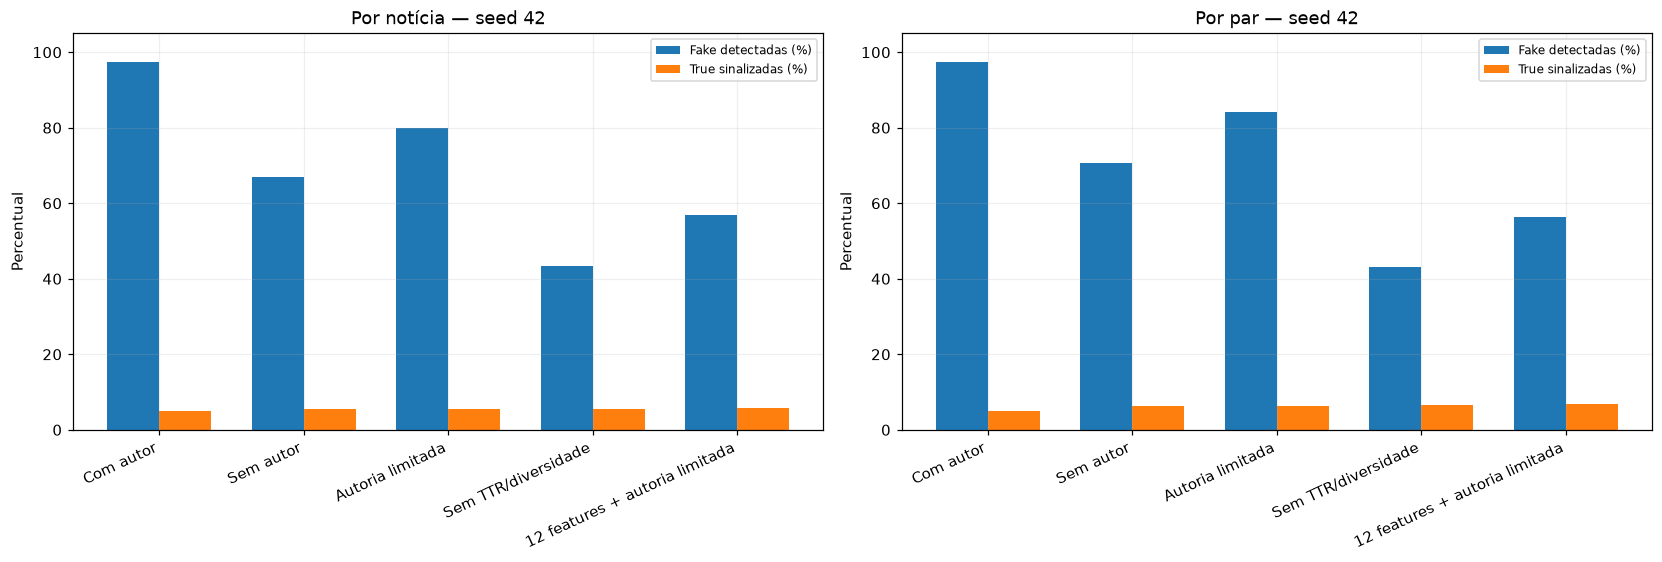

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)
for axis, protocol in zip(axes, ["Por notícia", "Por par"]):
    selected = evaluationFrame.loc[evaluationFrame["protocol"].eq(protocol) & evaluationFrame["seed"].eq(42)].set_index("model")
    x = np.arange(len(selected))
    axis.bar(x - 0.18, selected["recall"] * 100, width=0.36, label="Fake detectadas (%)")
    axis.bar(x + 0.18, selected["falsePositiveRate"] * 100, width=0.36, label="True sinalizadas (%)")
    axis.set_xticks(x, selected.index, rotation=25, ha="right")
    axis.set(title=f"{protocol} — seed 42", ylabel="Percentual", ylim=(0, 105))
    axis.legend(fontsize=8)
plt.show()

## 13. Conclusão simples e saída por notícia

Não escolheremos parâmetros olhando este teste. O ajuste limitado pode recuperar
parte do recall e também gerar novos falsos alertas. O resultado é reportado como
observado, sem promessa de recuperar o baseline nem comprovar falsidade.

In [20]:
for protocol in ["Por notícia", "Por par"]:
    selected = evaluationFrame.loc[evaluationFrame["protocol"].eq(protocol) & evaluationFrame["seed"].eq(42)].set_index("model")
    base = selected.loc["Sem autor"]
    controlled = selected.loc["Autoria limitada"]
    withAuthor = selected.loc["Com autor"]
    trainingCount = next(len(partitions["normalTrain"]) for name, seed, partitions in protocols if name == protocol and seed == 42)
    display(Markdown(f"""
**Resultado simples — {protocol}, seed 42.** Foram treinadas **{trainingCount} notícias True e nenhuma Fake**.
O teste contém **{int(base['trueCount'])} True e {int(base['fakeCount'])} Fake**.

- Com autor livre: **{int(withAuthor['truePositive'])} Fake detectadas** e **{int(withAuthor['falsePositive'])} True sinalizadas**.
- Sem autor: **{int(base['truePositive'])} Fake detectadas** e **{int(base['falsePositive'])} True sinalizadas**.
- Autoria limitada: **{int(controlled['truePositive'])} Fake detectadas** e **{int(controlled['falsePositive'])} True sinalizadas**.

O ajuste recuperou **{int(controlled['truePositive'] - base['truePositive'])} Fake** e acrescentou
**{int(controlled['falsePositive'] - base['falsePositive'])} alertas em True**.
Recall: **{base['recall']:.2%} → {controlled['recall']:.2%}**;
FPR: **{base['falsePositiveRate']:.2%} → {controlled['falsePositiveRate']:.2%}**.
Na validação normal, o FPR final da regra foi **{controlled['normalValidationFpr']:.2%}**.
"""))

exampleResults = resultFrames[("Por par", 42, "Autoria limitada")]
changedExamples = exampleResults.loc[exampleResults["authorAdjustment"].gt(0)].head(5)
display(changedExamples[["id", "label", "authorStatus", "anomalyScore", "authorAdjustment", "authorAdjustedScore", "isAnomalyBase", "isAnomaly"]])
display(Markdown("""
**Limites:** autoria identificada não foi verificada por identidade ou reputação;
status desconhecido foi testado sinteticamente; faltam notícias externas e uma
divisão por fonte/época. Os três splits agrupados reutilizam o mesmo corpus e não
são amostras independentes. Retirar TTR/diversidade não elimina todo sinal de
comprimento. Autoria tem influência limitada por construção, mas isso não garante
maior validade externa. **Anomalia não é sinônimo de falsidade.**
"""))


**Resultado simples — Por notícia, seed 42.** Foram treinadas **2160 notícias True e nenhuma Fake**.
O teste contém **720 True e 1800 Fake**.

- Com autor livre: **1752 Fake detectadas** e **35 True sinalizadas**.
- Sem autor: **1206 Fake detectadas** e **39 True sinalizadas**.
- Autoria limitada: **1439 Fake detectadas** e **40 True sinalizadas**.

O ajuste recuperou **233 Fake** e acrescentou
**1 alertas em True**.
Recall: **67.00% → 79.94%**;
FPR: **5.42% → 5.56%**.
Na validação normal, o FPR final da regra foi **5.00%**.



**Resultado simples — Por par, seed 42.** Foram treinadas **2160 notícias True e nenhuma Fake**.
O teste contém **720 True e 720 Fake**.

- Com autor livre: **702 Fake detectadas** e **35 True sinalizadas**.
- Sem autor: **509 Fake detectadas** e **45 True sinalizadas**.
- Autoria limitada: **606 Fake detectadas** e **46 True sinalizadas**.

O ajuste recuperou **97 Fake** e acrescentou
**1 alertas em True**.
Recall: **70.69% → 84.17%**;
FPR: **6.25% → 6.39%**.
Na validação normal, o FPR final da regra foi **5.00%**.


,id,label,authorStatus,anomalyScore,authorAdjustment,authorAdjustedScore,isAnomalyBase,isAnomaly
308,2394t,0,not_reported,-0.007735,0.024148,0.016413,False,True
726,1045,1,not_reported,0.009608,0.024148,0.033756,False,True
733,1071,1,not_reported,0.010987,0.024148,0.035135,False,True
745,1138,1,not_reported,0.003923,0.024148,0.028071,False,True
750,1149,1,not_reported,0.002732,0.024148,0.026880,False,True



**Limites:** autoria identificada não foi verificada por identidade ou reputação;
status desconhecido foi testado sinteticamente; faltam notícias externas e uma
divisão por fonte/época. Os três splits agrupados reutilizam o mesmo corpus e não
são amostras independentes. Retirar TTR/diversidade não elimina todo sinal de
comprimento. Autoria tem influência limitada por construção, mas isso não garante
maior validade externa. **Anomalia não é sinônimo de falsidade.**
